### Overview
-> Obtain the wind data from Maspolomas 
-> Clean this data, find any anomalies -> document said anomalies 
-> Plot the graphs


In [ ]:
# Modules
import requests
import pandas as pd
import seaborn as sns
import ee
import pygame as pg
from statsmodels.tsa.seasonal import seasonal_decompose

- The requests module handles HTTP requests (GET, POST, etc) to web APIs. In this instance, the ``GET method`` is used to structure a query to obtain a response containing wind speed, wind gust and wind direction from [open mateo](open-meteo.com)

- The pandas module provides the resources for reading and writing data, e.g. writing to a ```csv file``` or to opening a ```json file```, and manipulating data for merging, joining or aggregation. 

- The seaborn library is used to develop statistical visualizations with in-built styling. This ensures less time is spent on attractive visualisations and more time revealing data patterns, e.g. distribution plots, heatmaps, regression analysis etc.

- Google Earth's Engine is used to 

In [39]:
# Load coordinates, start and end dates from utils.json using pandas
# typ='series' allows us to access the data as key-value pairs
utils = pd.read_json('utils.json', typ='series')

# Define CSV filename where the wind data will be saved
csv_filename = 'wind_data_2020_2021.csv'

# Creates a request to Open-Meteo Historical Weather API
url = "https://archive-api.open-meteo.com/v1/archive"

# Prepare parameters for the API request
# All parameters are taken from the utils.json file
params = {
    "latitude": utils["lat"],
    "longitude": utils["lon"],
    "start_date": utils["start_date"],
    "end_date": utils["end_date"],
    "hourly": "wind_speed_10m,wind_direction_10m,wind_gusts_10m",
    "timezone": "auto"
}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    
    # Create DataFrame directly from the API response
    df = pd.DataFrame({
        'datetime': data['hourly']['time'],
        'wind_speed': data['hourly']['wind_speed_10m'],
        'wind_direction': data['hourly']['wind_direction_10m'],
        'wind_gusts': data['hourly']['wind_gusts_10m']
    })
    
    # Write to CSV using pandas
    df.to_csv(csv_filename, index=False)
    
    print(f"Successfully saved {len(df)} hours of wind data to {csv_filename}")
    print(f"Data includes: wind speed, direction, and gusts (all at 10m height)")
    
else:
    print(f"Error: {response.status_code}")
    print(response.text)

Successfully saved 17544 hours of wind data to wind_data_2020_2021.csv
Data includes: wind speed, direction, and gusts (all at 10m height)


In [40]:
df = pd.read_csv('wind_data_2020_2021.csv')
df.describe()

,wind_speed,wind_direction,wind_gusts
count,17544.000000,17544.000000,17544.000000
mean,16.374612,122.837494,26.458881
std,7.090365,92.363454,10.467982
min,0.000000,1.000000,1.100000
25%,11.500000,53.000000,19.100000
50%,16.100000,90.000000,25.900000
75%,20.900000,171.000000,33.100000
max,49.800000,360.000000,76.300000


In [ ]:
# Counts the number of zero wind entries
zero_count = (df['wind_speed'] == 0).sum()
# Returns any zero wind speed observations then the corresponding datetime, wind speed, direction, and gusts
zero_wind_data = df[df['wind_speed'] == 0]

print(f"Number of zero wind speed entries: {zero_count}")
print("\nZero wind speed observations:")
print(zero_wind_data[['datetime', 'wind_speed', 'wind_direction', 'wind_gusts']])

Number of zero wind speed entries: 2

Zero wind speed observations:
              datetime  wind_speed  wind_direction  wind_gusts
1026  2020-02-12T18:00         0.0             270        10.1
4332  2020-06-29T12:00         0.0             270        14.8


Entries with ``0`` suggest that wind was present but below the sensor's minimum threshold. [Open-Meteo](https://open-meteo.com/en/about) does not provide information on the types of sensors used to obtain metrological data. Given this issue - and it's occurance < 1.39 % a proxy value of 0.1 is used. 

In [48]:
df['wind_speed'] = df['wind_speed'].replace(0, 0.1)
print(f'Check if zero wind speed entries are replaced with 0.1: {(df["wind_speed"] == 0.1).sum()}')

Check if zero wind speed entries are replaced with 0.1: 2


Wind gusts must also be checked against wind speed as wind gusts by definition are typically higher or equal to the sustained wind speed [Met Office](https://weather.metoffice.gov.uk/guides/observations/how-we-measure-wind)

In [49]:
# Check for impossible physics: gusts < sustained wind
impossible = df[df['wind_gusts'] < df['wind_speed']]
print(f"Impossible observations (gusts < wind speed): {len(impossible)}")

Impossible observations (gusts < wind speed): 35


In [ ]:
# Look at the problematic data
print("Impossible observations:")
print(impossible[['datetime', 'wind_speed', 'wind_direction', 'wind_gusts']])

# This checks the severity of the problem
print(f"\nDifference analysis:")
print(f"Average wind speed in impossible cases: {impossible['wind_speed'].mean():.2f}")
print(f"Average gusts in impossible cases: {impossible['wind_gusts'].mean():.2f}")
print(f"Average difference (wind - gusts): {(impossible['wind_speed'] - impossible['wind_gusts']).mean():.2f}")

Impossible observations:
               datetime  wind_speed  wind_direction  wind_gusts
105    2020-01-05T09:00         1.5             135         1.4
1341   2020-02-25T21:00         3.3             221         3.2
1898   2020-03-20T02:00        13.6              50        11.9
2258   2020-04-04T02:00        21.6             298        15.8
2445   2020-04-11T21:00         8.9              47         7.6
3118   2020-05-09T22:00         7.4              47         6.8
4130   2020-06-21T02:00         6.5             161         6.1
5282   2020-08-08T02:00        24.5              87        19.4
5666   2020-08-24T02:00        13.5              42        12.6
7874   2020-11-24T02:00        12.4             330        11.9
8210   2020-12-08T02:00         9.4              18         9.0
8517   2020-12-20T21:00         5.0              60         4.7
8858   2021-01-04T02:00         8.0             333         5.4
8978   2021-01-09T02:00         5.6             105         4.0
9120   2021-01-

In [51]:
# Fix by setting gusts equal to wind speed for these cases
# This is the most conservative approach that maintains data integrity
df.loc[impossible.index, 'wind_gusts'] = df.loc[impossible.index, 'wind_speed']

print(f"Fixed {len(impossible)} impossible observations by setting gusts = wind speed")

# Verify the fix
check = df[df['wind_gusts'] < df['wind_speed']]
print(f"Remaining impossible observations: {len(check)}")

Fixed 35 impossible observations by setting gusts = wind speed
Remaining impossible observations: 0


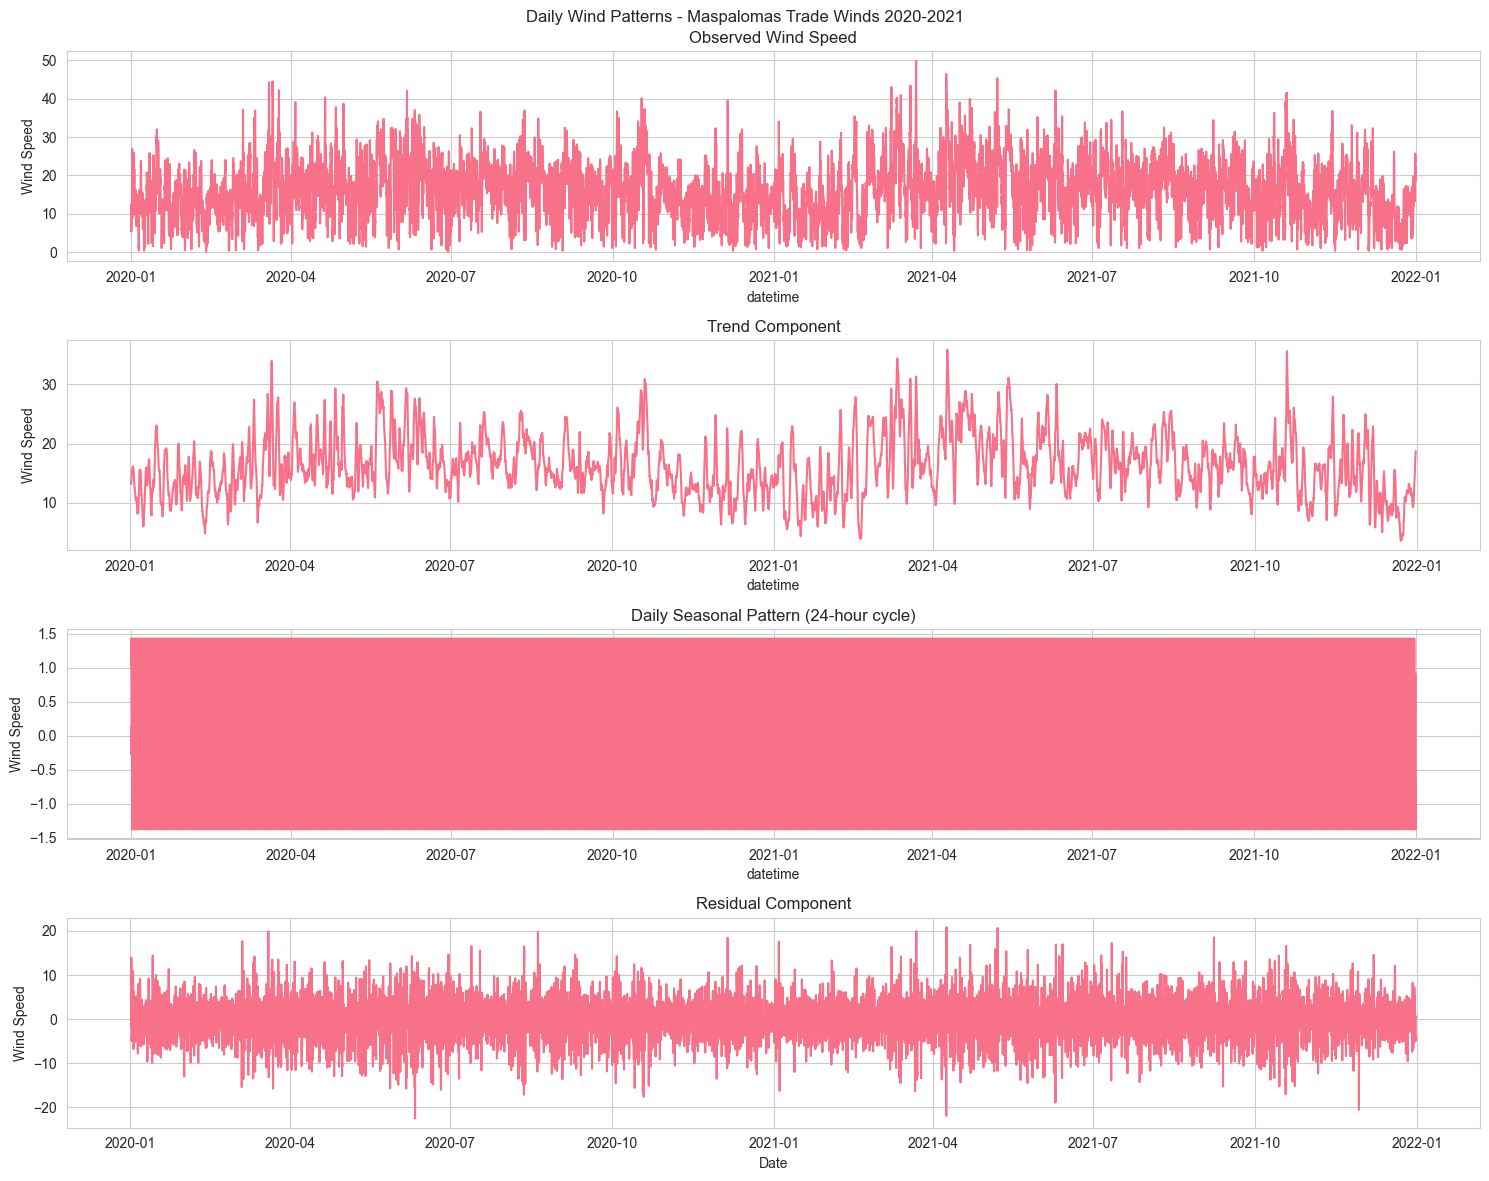

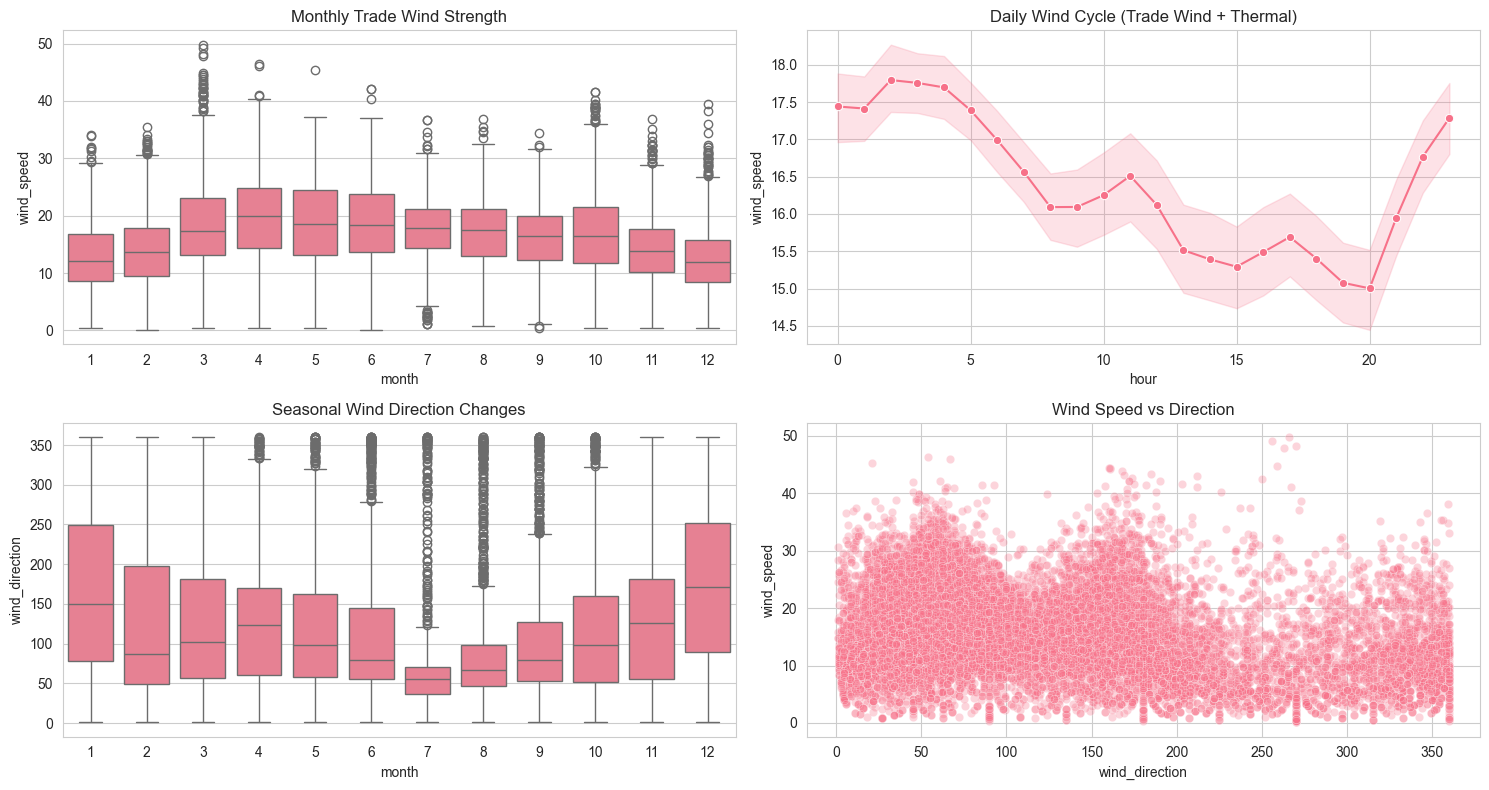

In [ ]:
sns.set_style("whitegrid")
sns.set_palette("husl")


df['datetime'] = pd.to_datetime(df['datetime'])
df_ts = df.set_index('datetime')


daily_decomp = seasonal_decompose(df_ts['wind_speed'], 
                                model='additive',
                                period=24)


fig, axes = plt.subplots(4, 1, figsize=(15, 12))


sns.lineplot(x=daily_decomp.observed.index, y=daily_decomp.observed.values, ax=axes[0])
axes[0].set_title('Observed Wind Speed')
axes[0].set_ylabel('Wind Speed')

sns.lineplot(x=daily_decomp.trend.index, y=daily_decomp.trend.values, ax=axes[1])
axes[1].set_title('Trend Component')
axes[1].set_ylabel('Wind Speed')

sns.lineplot(x=daily_decomp.seasonal.index, y=daily_decomp.seasonal.values, ax=axes[2])
axes[2].set_title('Daily Seasonal Pattern (24-hour cycle)')
axes[2].set_ylabel('Wind Speed')

sns.lineplot(x=daily_decomp.resid.index, y=daily_decomp.resid.values, ax=axes[3])
axes[3].set_title('Residual Component')
axes[3].set_ylabel('Wind Speed')
axes[3].set_xlabel('Date')

plt.suptitle('Daily Wind Patterns - Maspalomas Trade Winds 2020-2021')
plt.tight_layout()
plt.show()


df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour

fig, axes = plt.subplots(2, 2, figsize=(15, 8))


sns.boxplot(data=df, x='month', y='wind_speed', ax=axes[0,0])
axes[0,0].set_title('Monthly Trade Wind Strength')


sns.lineplot(data=df, x='hour', y='wind_speed', ax=axes[0,1], marker='o')
axes[0,1].set_title('Daily Wind Cycle (Trade Wind + Thermal)')


sns.boxplot(data=df, x='month', y='wind_direction', ax=axes[1,0])
axes[1,0].set_title('Seasonal Wind Direction Changes')


sns.scatterplot(data=df, x='wind_direction', y='wind_speed', alpha=0.3, ax=axes[1,1])
axes[1,1].set_title('Wind Speed vs Direction')

plt.tight_layout()
plt.show()